In [ ]:
!rm -rf Mislata_proyecto # borrar el repositorio por si ya esta
!git clone https://github.com/{name}/Mislata_proyecto.git

Cloning into 'Mislata_proyecto'...
remote: Enumerating objects: 1940, done.
remote: Counting objects: 100% (592/592), done.
remote: Compressing objects: 100% (410/410), done.
remote: Total 1940 (delta 505), reused 184 (delta 182), pack-reused 1348 (from 3)
Receiving objects: 100% (1940/1940), 16.85 MiB | 11.01 MiB/s, done.
Resolving deltas: 100% (1299/1299), done.


In [ ]:
import base64
import requests
import pandas as pd
import json
import os
from pathlib import Path

def guardar_ficheros(owner, repo, upload_path, nombre_limpio, df_limpio):
    csv_bytes = df_limpio.to_csv(index=False).encode('utf-8')
    csv_base64 = base64.b64encode(csv_bytes).decode('utf-8')

    # Construir URL para subir el archivo
    upload_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{upload_path}/{nombre_limpio}"

    # Verificar si el archivo ya existe
    check = requests.get(upload_url, headers=headers)
    if check.status_code == 200:
        sha = check.json()['sha']
    else:
        sha = None

    # Crear o actualizar el archivo en el repo
    payload = {
        "message": f"Subiendo archivo procesado: {nombre_limpio}",
        "content": csv_base64,
        "branch": branch
    }

    if sha:
        payload["sha"] = sha  # Si existe, será update

    r = requests.put(upload_url, headers=headers, json=payload)
    if r.status_code in [200, 201]:
        print(f"✅ {nombre_limpio} subido correctamente al repo.")
    else:
        print(f"❌ Error al subir {nombre_limpio}: {r.json()}")


In [ ]:
import requests
import pandas as pd
import json
import os
from pathlib import Path

# Configuración
path = "data/data_bronze"
api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}"
raw_base_url = f"https://raw.githubusercontent.com/{owner}/{repo}/main/{path}"


# Obtener lista de archivos del repositorio
response = requests.get(api_url)
if response.status_code != 200:
    raise Exception(f"No se pudo obtener la lista de archivos: {response.text}")

archivos = [f["name"] for f in response.json() if f["name"].endswith(".csv")]

# === PROCESAR CADA ARCHIVO Y SUBIRLO A GITHUB ===
headers = {
    "Authorization": f"token {token}",
    "Accept": "application/vnd.github.v3+json"
}

In [ ]:
import numpy as np

path_read = 'data/test/entrenamiento_neuronal_calefaccion.csv'
df = pd.read_csv(f'https://raw.githubusercontent.com/{owner}/{repo}/main/{path_read}', parse_dates=['time'])

df['time'] = pd.to_datetime(df['time'])
df['hora'] = df['time'].dt.hour
df['part_of_day'] = df['hora'].apply(lambda h: (
    0 if h < 6 else #Madrugada = 0
    3 if h < 12 else #Mañana = 3
    2 if h < 18 else  #Tarde = 2
    1 #Noche = 1
))

df['mes'] = df['time'].dt.month
df['season'] = df['hora'].apply(lambda h: (
    0 if h in [12,1,2] else #Invierno = 0
    1 if h in [3,4,5] else #Primavera = 1
    2 if h in [6,7,8] else #Verano = 2
    3 #Otoño = 3
))

df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 23)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 23)

df["dia_semana"] = df["time"].dt.dayofweek  # Día de la semana (0=lunes)
# Codificación one-hot para dia_semana (ahora solo contiene 0 a 4)
df = pd.get_dummies(df, columns=['dia_semana'], prefix='dia', drop_first=True)

# probar tasas de aprendizaje, funciones activacion y num neuronas
df.to_csv('entrenamiento_neuronal_calefaccion.csv', index=False)

In [ ]:
# Eliminar las columnas especificadas
columns_to_drop = [
    "time"
]
df_cleaned = df.drop(columns=columns_to_drop)

# Confirmar las columnas restantes
df_cleaned.columns

Index(['sensor.sensor_temperatura_1_humidity',
       'sensor.sensor_temperatura_1_pressure',
       'sensor.sensor_temperatura_1_temperature', 'sensor_puerta_1 Puerta',
       'suma_ventanas_arriba', 'suma_ventanas_abajo', 'azimuth_mean',
       'elevacion_sol', 'temperatura_exterior', 'porcentaje_nubes',
       'temperatura_calefaccion_y', 'hora', 'part_of_day', 'mes', 'season',
       'hora_sin', 'hora_cos', 'dia_1', 'dia_2', 'dia_3', 'dia_4', 'dia_5',
       'dia_6', 'dia_1', 'dia_2', 'dia_3', 'dia_4', 'dia_5', 'dia_6'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Separar características (X) y variable objetivo (y)
X = df_cleaned.drop(columns=["temperatura_calefaccion_y"])
y = df_cleaned["temperatura_calefaccion_y"]

# Normalización de características
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Verificar formas
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1997, 28), (500, 28), (1997,), (500,))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Crear una red neuronal super mega grande
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=500,
    verbose=0
)

# Guardar historial de entrenamiento
history_df = pd.DataFrame(history.history)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


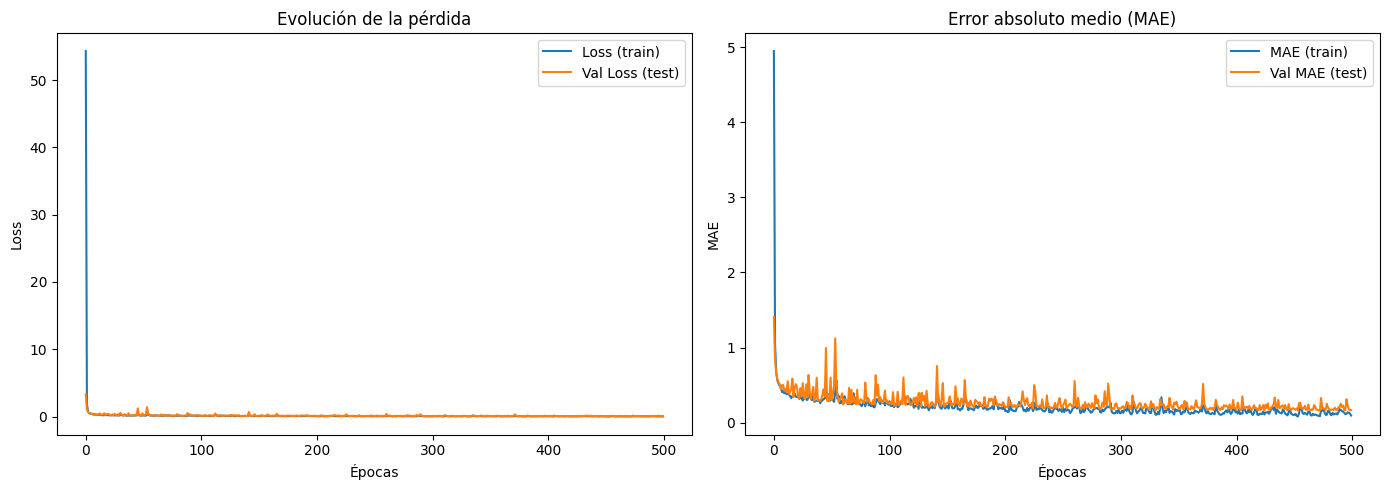

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convertir el historial a DataFrame
history_df = pd.DataFrame(history.history)

# Graficar la pérdida
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_df['loss'], label='Loss (train)')
plt.plot(history_df['val_loss'], label='Val Loss (test)')
plt.title('Evolución de la pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Graficar MAE
plt.subplot(1, 2, 2)
plt.plot(history_df['mae'], label='MAE (train)')
plt.plot(history_df['val_mae'], label='Val MAE (test)')
plt.title('Error absoluto medio (MAE)')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
"""# Hacer predicciones con el modelo sobre el conjunto de test
y_pred = model.predict(X_test).flatten()

# Crear una copia del DataFrame original con las filas correspondientes a X_test
df_test = df_cleaned.iloc[y_test.index].copy()

# Añadir columna con las predicciones
df_test["predic temperatura aula"] = y_pred

output_path = "predicciones_temperatura_aula.csv"
df_test.to_csv(output_path, index=False)
output_path

model.save("model_predict_temperaturas.keras")

df_test"""

'# Hacer predicciones con el modelo sobre el conjunto de test\ny_pred = model.predict(X_test).flatten()\n\n# Crear una copia del DataFrame original con las filas correspondientes a X_test\ndf_test = df_cleaned.iloc[y_test.index].copy()\n\n# Añadir columna con las predicciones\ndf_test["predic temperatura aula"] = y_pred\n\noutput_path = "predicciones_temperatura_aula.csv"\ndf_test.to_csv(output_path, index=False)\noutput_path\n\nmodel.save("model_predict_temperaturas.keras")\n\ndf_test'